## Dimensionality Reduction Embeddigins by segment and subsample

In [102]:
from pathlib import Path
import pandas as pd

# Path to your folder
folder_path = Path("/data/users/ltucker/influenzaData/pipeline/output/jupyter_outputs/nanduri_params/embeddings")

# Dictionary to store dataframes with file names (without extension) as keys
all_data = {}

# Iterate through all CSV files in the folder
for file in folder_path.glob("*.csv"):
    all_data[file.stem] = pd.read_csv(file)
    print (f"processed {file.stem}")

processed segment_6_tsne_100pct_seed_6004
processed segment_1_tsne_100pct_seed_6002
processed segment_6_umap_50pct_seed_4004
processed segment_5_umap_50pct_seed_4003
processed segment_0_umap_5pct_seed_2
processed segment_7_tsne_5pct_seed_2
processed segment_1_mds_20pct_seed_2003
processed segment_3_mds_20pct_seed_2000
processed segment_3_mds_20pct_seed_2001
processed segment_2_umap_5pct_seed_1
processed segment_0_umap_30pct_seed_3000
processed segment_1_tsne_50pct_seed_4003
processed segment_5_mds_5pct_seed_3
processed segment_6_tsne_70pct_seed_5001
processed segment_3_umap_10pct_seed_1001
processed segment_6_tsne_70pct_seed_5002
processed segment_7_umap_30pct_seed_3002
processed segment_6_mds_70pct_seed_5003
processed segment_7_umap_100pct_seed_6000
processed segment_3_tsne_5pct_seed_3
processed segment_3_tsne_70pct_seed_5000
processed segment_2_mds_20pct_seed_2001
processed segment_1_umap_10pct_seed_1003
processed segment_1_umap_50pct_seed_4002
processed segment_1_tsne_50pct_seed_400

In [103]:
def subset_data(dim_reduction_method = "umap", segment = "segment_1"):
# arguments for dim_reduction_method are umap, mds, or tsne, 
# arguments for segments for segment_0-7
    umap_0_subset = dict()
    
    for csv_name, data in all_data.items():
        base_name = csv_name.split("_seed_")[0]  # remove the seed
        # check if it matches segment & method, and if we haven't added it yet
        if dim_reduction_method in base_name and segment in base_name and base_name not in umap_0_subset:
            umap_0_subset[base_name] = data  # store base_name as key
     
    return (umap_0_subset)


In [125]:
def plot_dim_reduction (dim_reduction_method="umap"):
    fig, axes = plt.subplots(7, 7, figsize=(20, 20))
    
    percentages = ["5pct", "10pct", "20pct", "30pct", "50pct", "70pct", "100pct"]
    
    for segment_number in range(7):
        # print(f"segment_{segment_number}")
        subset = subset_data(dim_reduction_method = dim_reduction_method, segment = f"segment_{segment_number}")
        
        for plot_x_pos, pct in enumerate(percentages):
                # Find the key that ends with this percentage
                key = next((k for k in subset if k.endswith(f"_{pct}")), None)
                if key:
                    data = subset[key]
                    # print(f"Plot position {plot_x_pos}: {key}")
    
                    ax = axes[segment_number, plot_x_pos]
                    
                    # Plot da points
                    ax.scatter(data[f'{dim_reduction_method}_dim1'],
                               data[f'{dim_reduction_method}_dim2'], 
                               s=5, 
                               alpha=0.7)
                    ax.set_title(key.replace("_", " "), fontsize=15)
                    ax.axis("off")
                    
    fig.suptitle(f'{dim_reduction_method.upper()} Embeddings Across Segments And Subsampling Levels', fontsize=30)
     
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

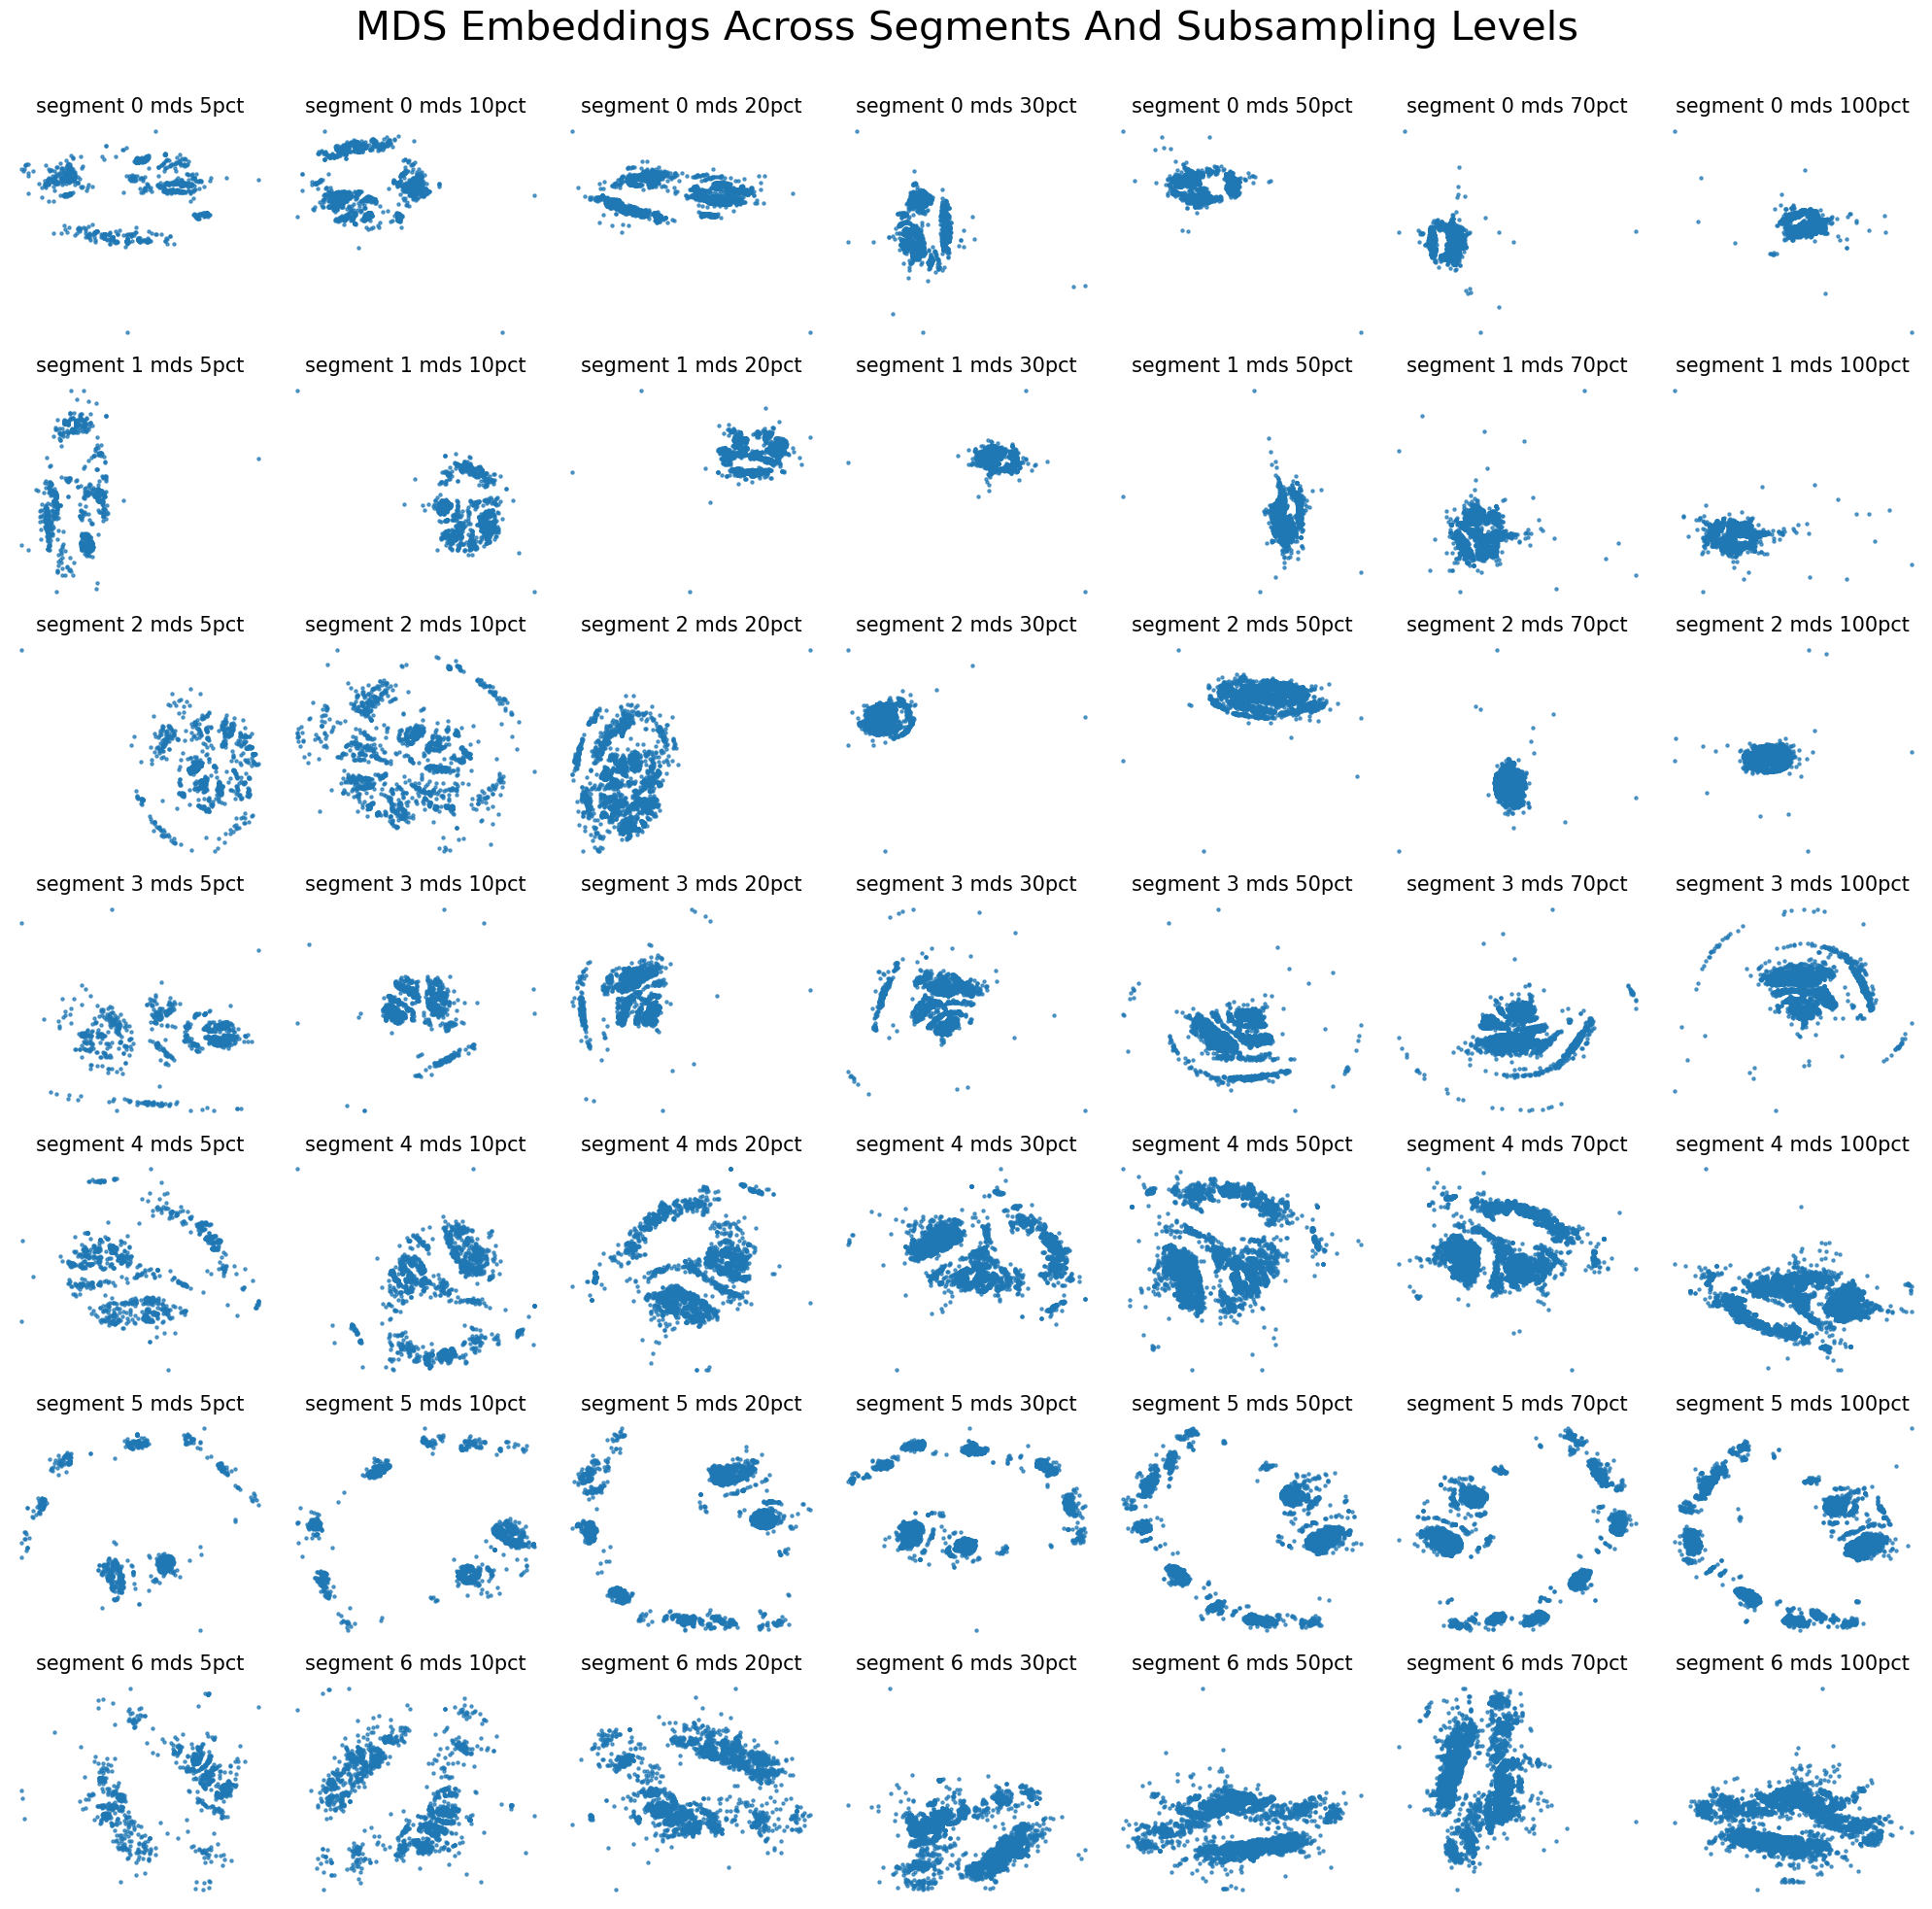

In [126]:
plot_dim_reduction(dim_reduction_method="mds")

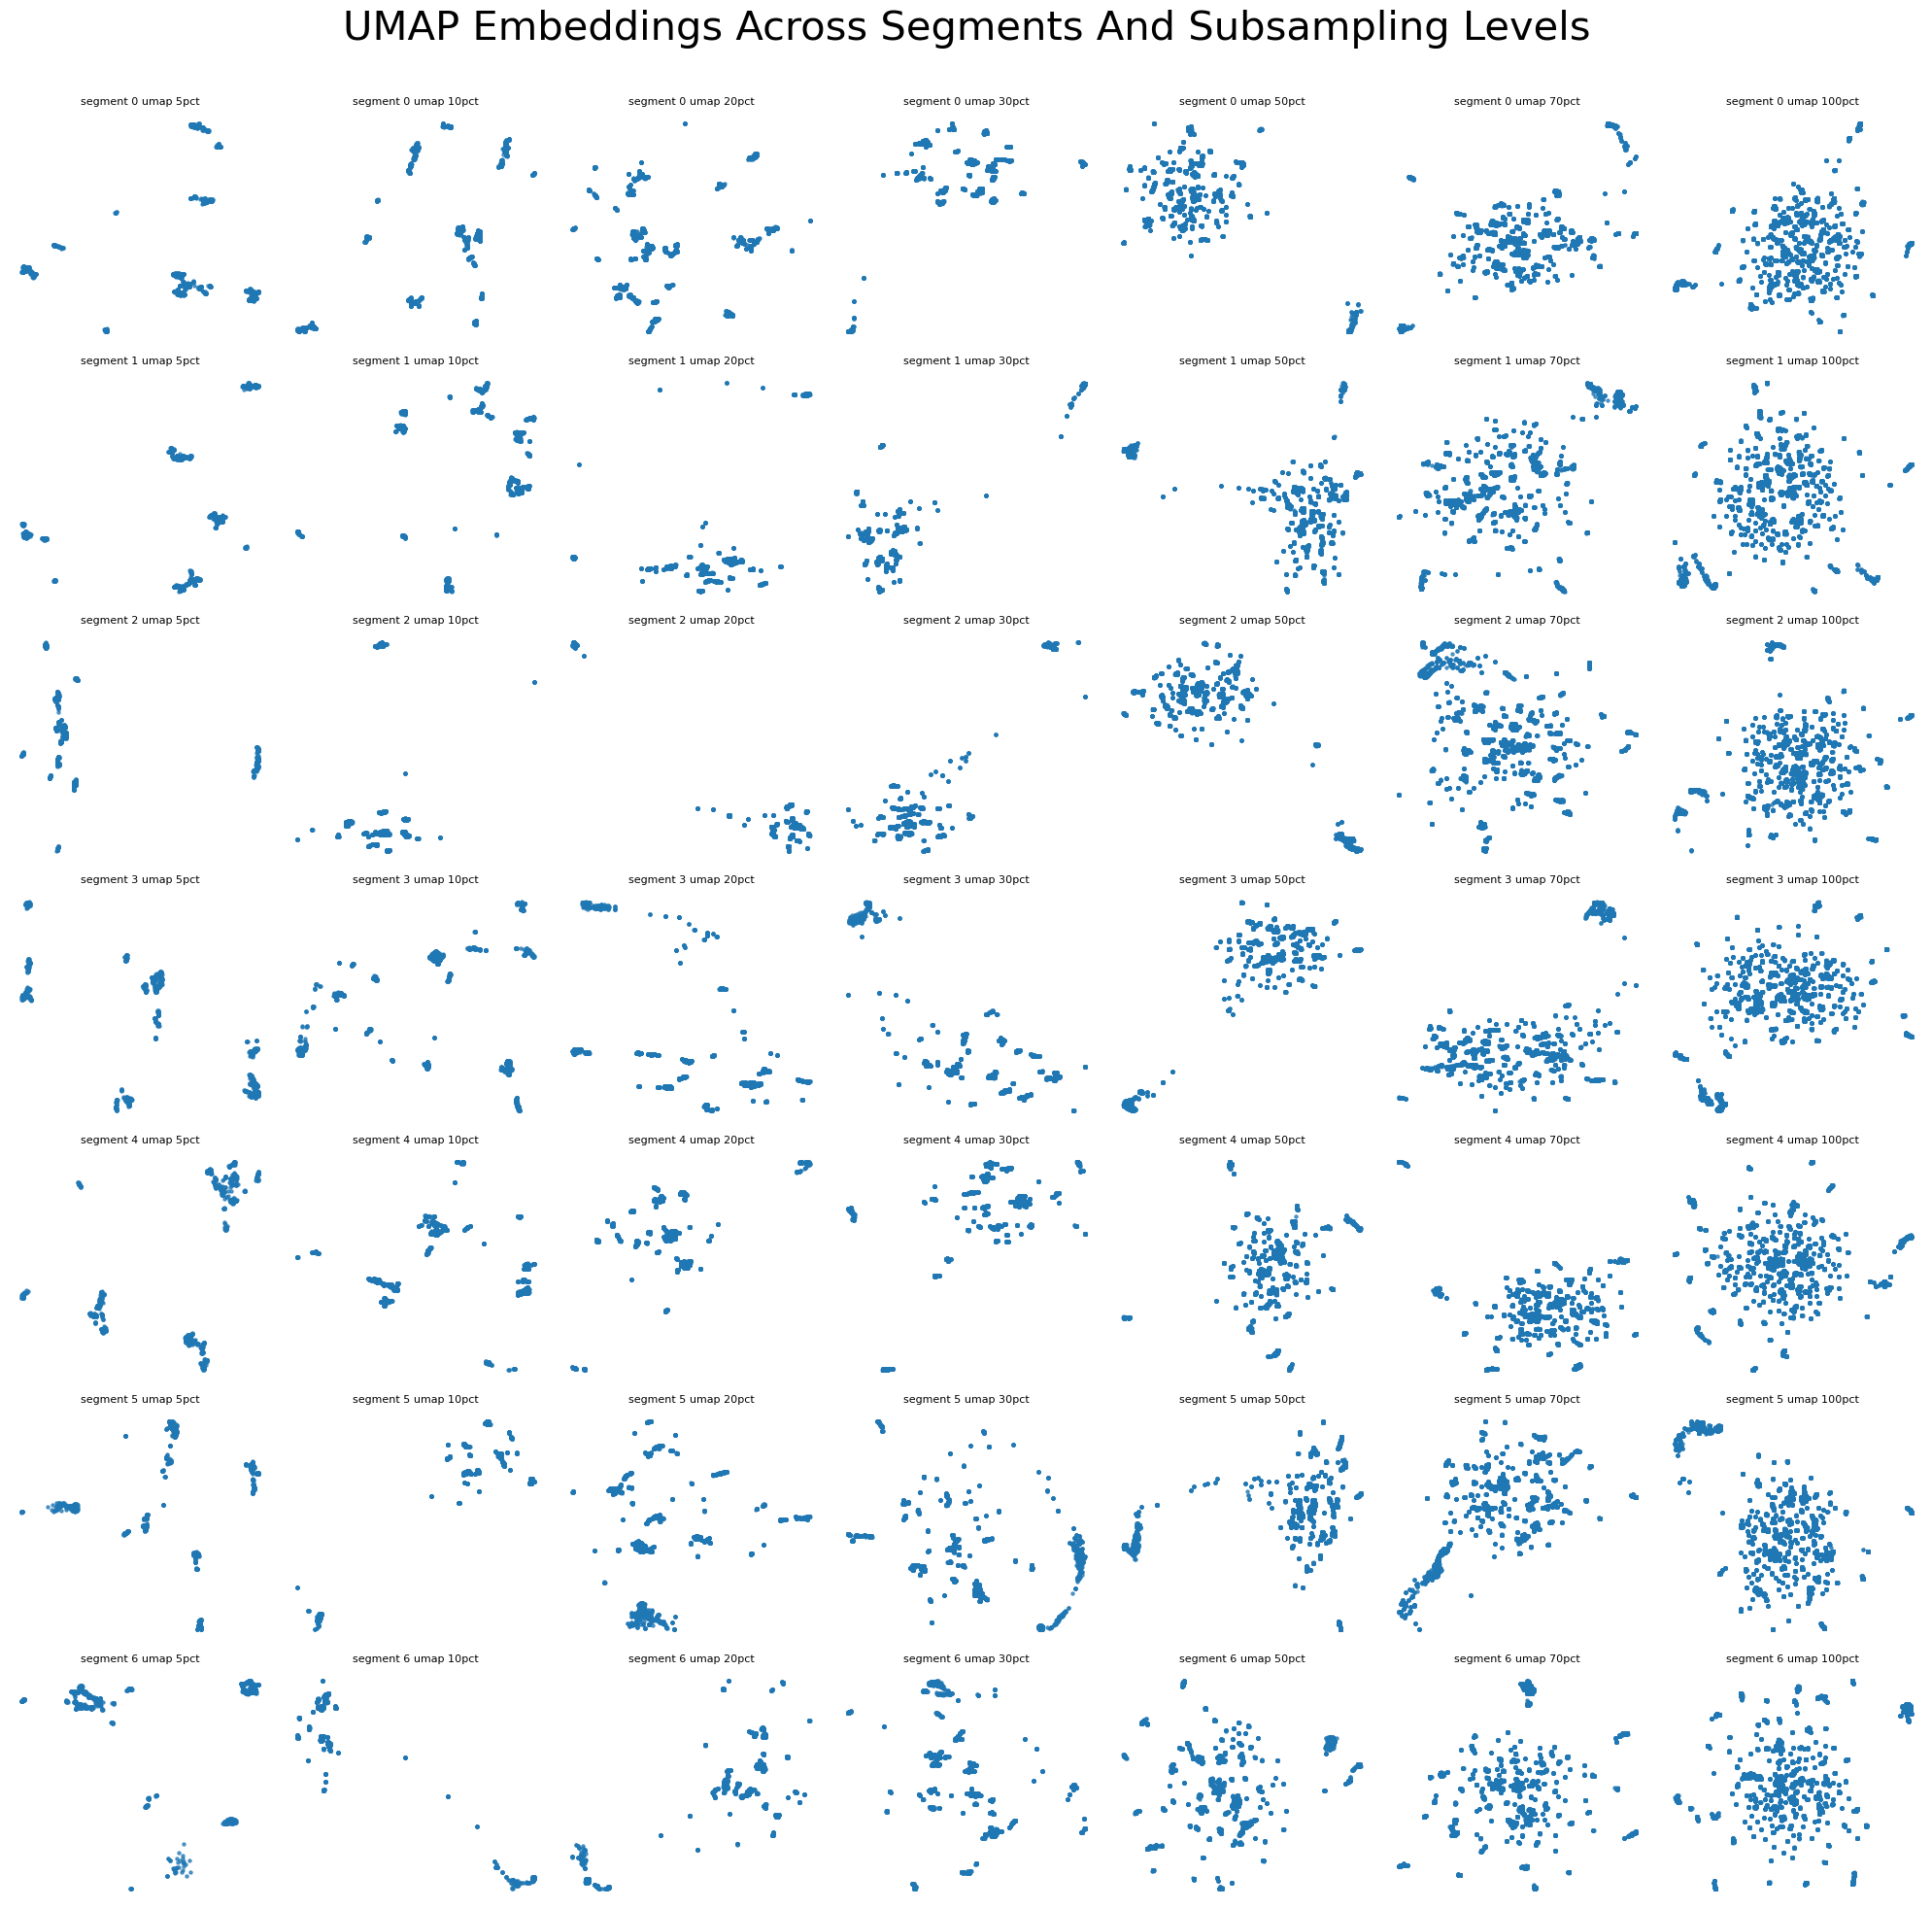

In [123]:
plot_dim_reduction(dim_reduction_method="umap")

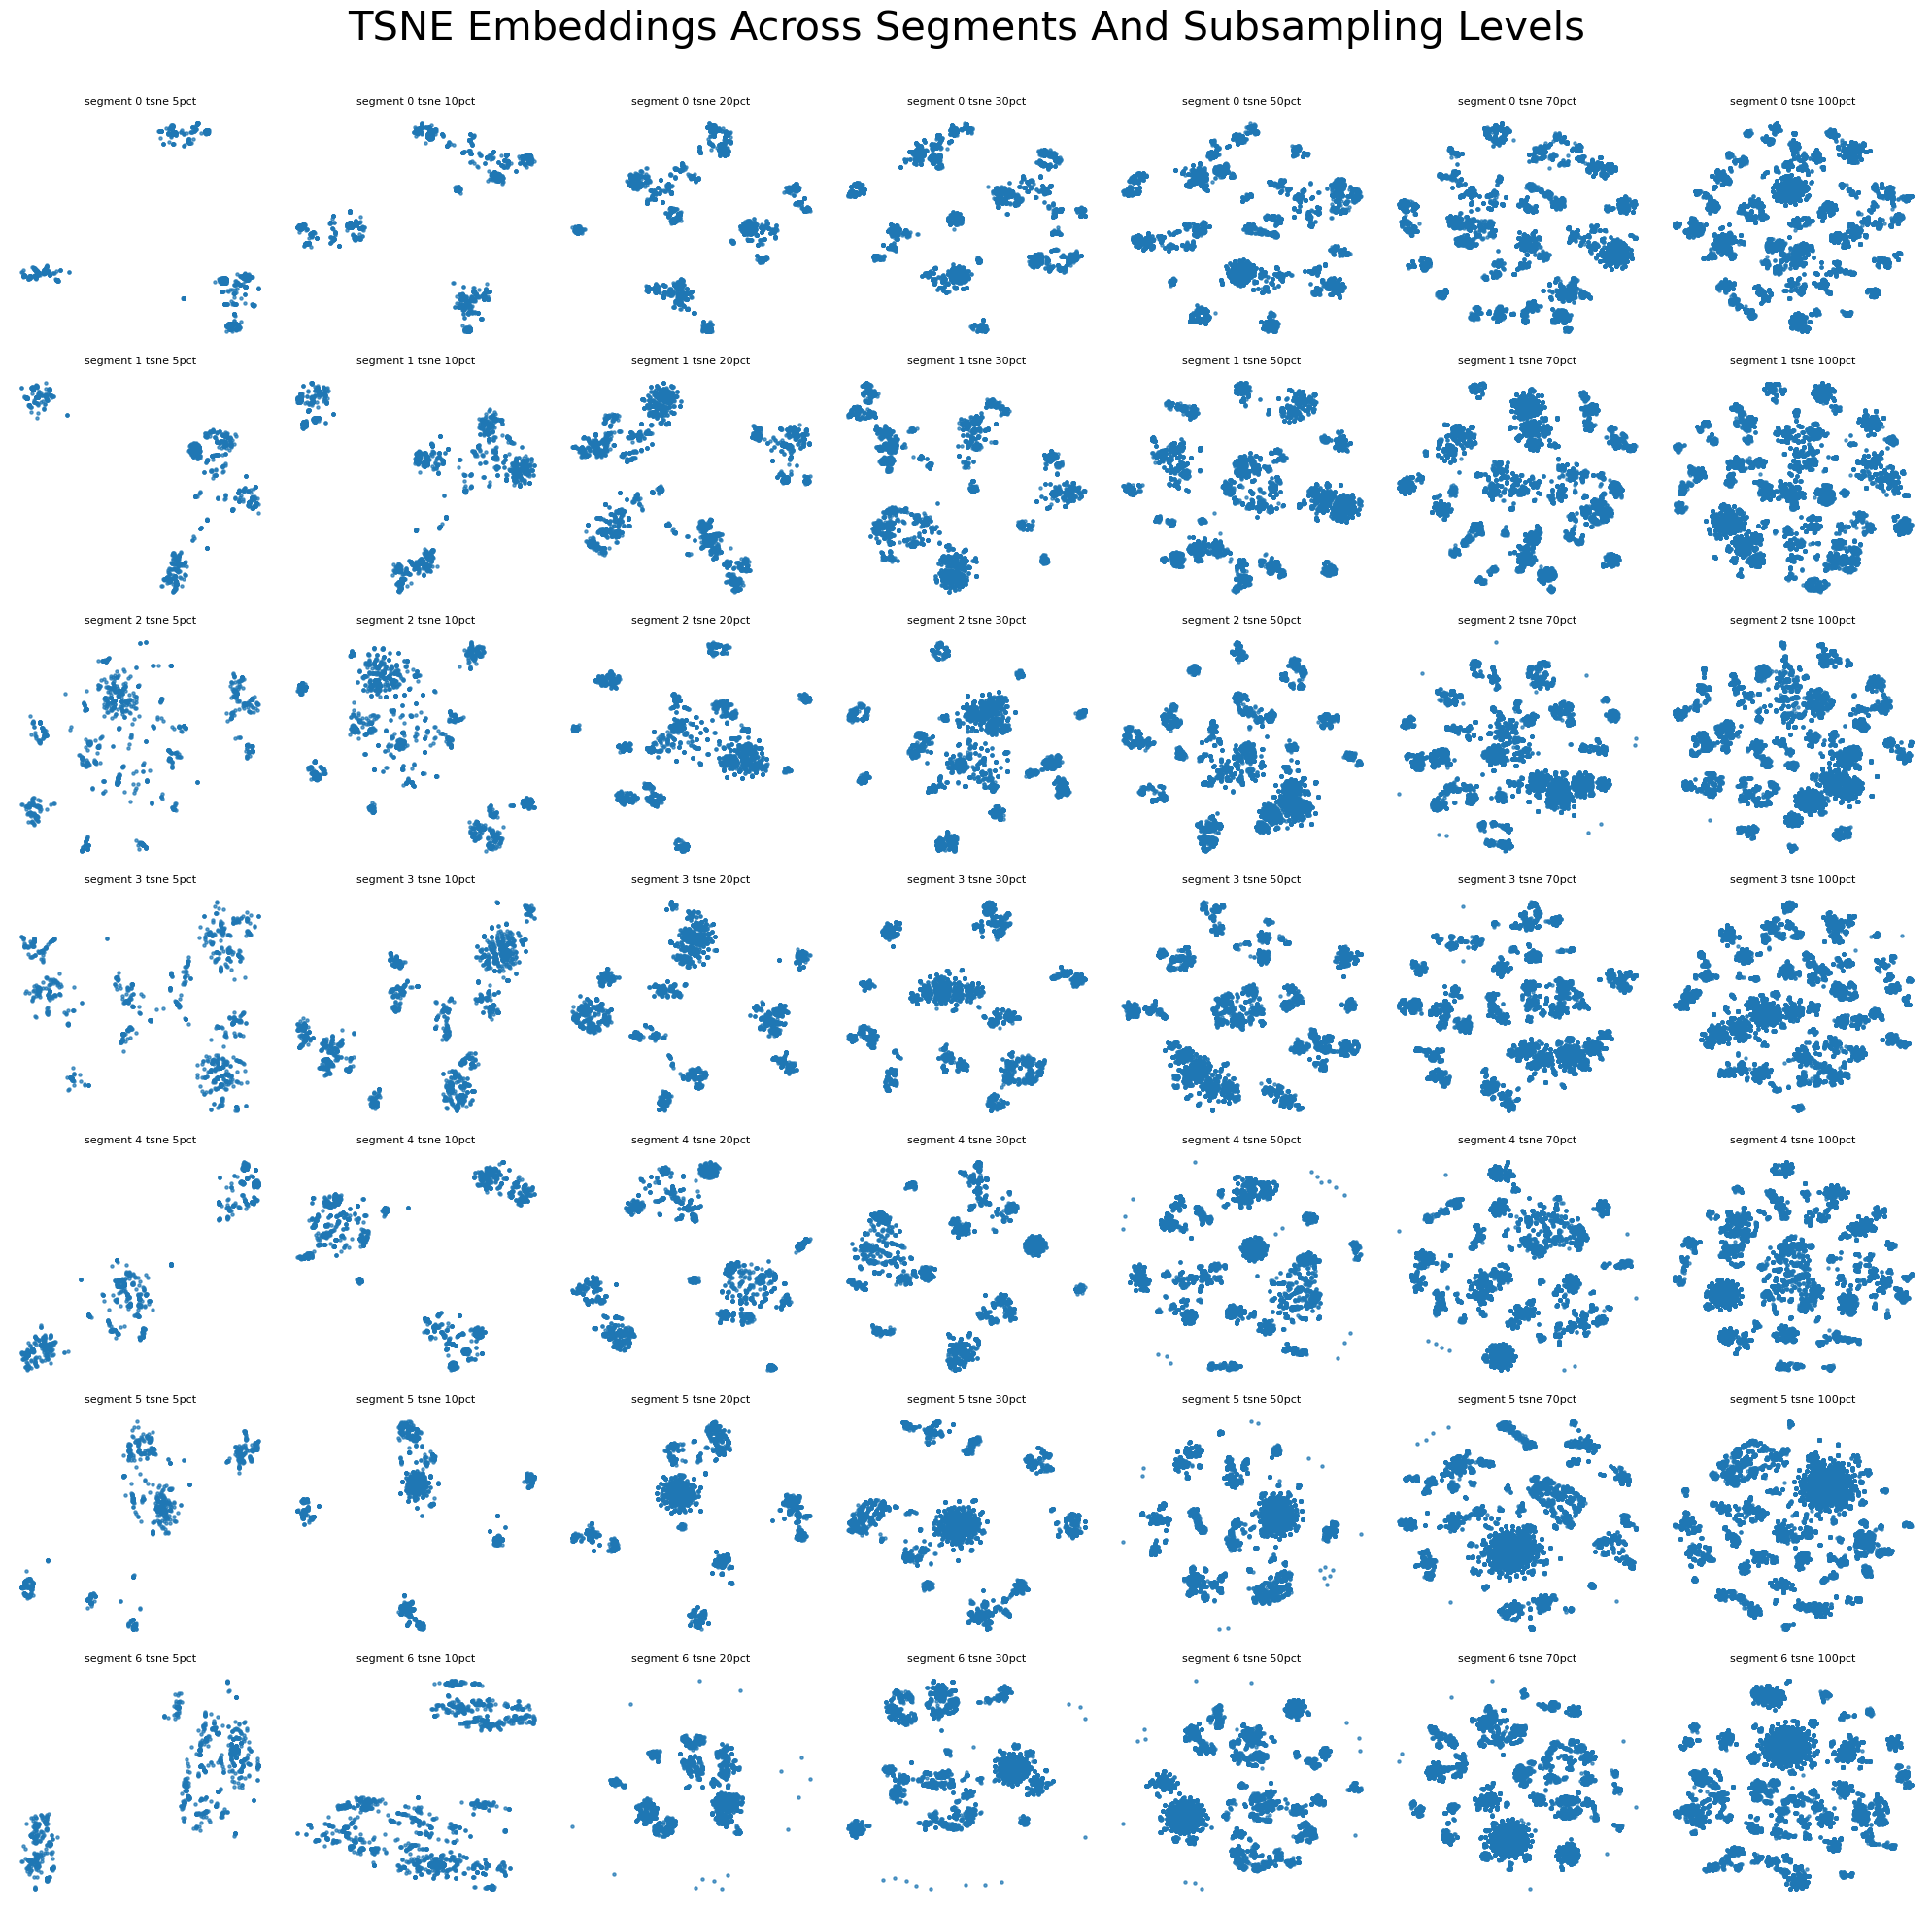

In [124]:
plot_dim_reduction(dim_reduction_method="tsne")

In [152]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path("/data/users/ltucker/influenzaData/pipeline/output/jupyter_outputs/nanduri_params")

# Load all segment summary CSVs
all_files = sorted(output_dir.glob("embedding_scaling_segment_*_detailed.csv"))

dfs = []
for f in all_files:
    if "detailed" in f.name:   # avoid loading detailed files
        df = pd.read_csv(f)
        dfs.append(df)

df_all_segments = pd.concat(dfs, ignore_index=True)

print(df_all_segments.head())

   segment  percentage  n_samples  repeat  seed  tsne_correlation  \
0        0         5.0       1116       0     0          0.879569   
1        0         5.0       1116       1     1          0.876377   
2        0         5.0       1116       2     2          0.899996   
3        0         5.0       1116       3     3          0.881943   
4        0         5.0       1116       4     4          0.896856   

   umap_correlation  mds_correlation  tsne_trustworthiness  \
0          0.547730         0.840104              0.990818   
1          0.618584         0.844054              0.989326   
2          0.798931         0.836181              0.990613   
3          0.788495         0.836174              0.989581   
4          0.448967         0.841662              0.990881   

   umap_trustworthiness  mds_trustworthiness  mds_stress  \
0              0.984921             0.969131  136.074789   
1              0.985105             0.971572  126.140945   
2              0.987967         

/tmp/ipykernel_3141856/3585350658.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_segments)  # 'tab10' has 10 distinct colors


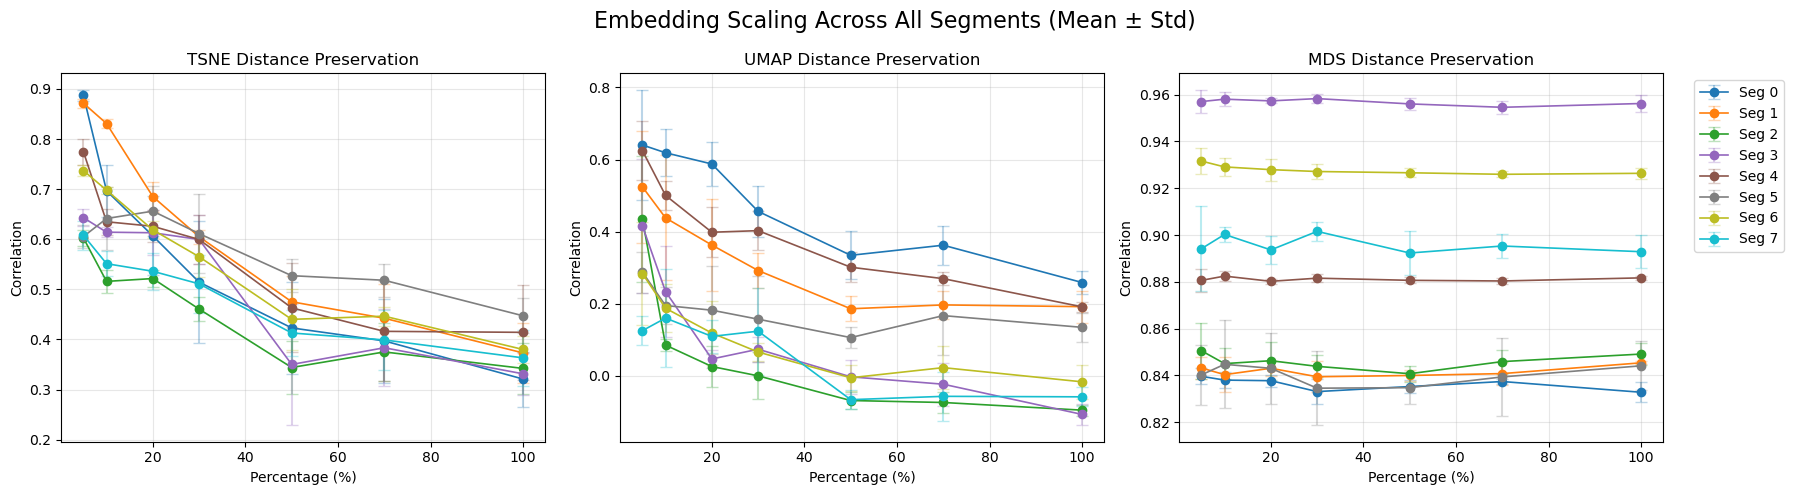

In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

methods = ["tsne", "umap", "mds"]

# Compute mean and std per segment and percentage
df_summary = df_all_segments.groupby(['segment', 'percentage']).agg(
    tsne_corr_mean=('tsne_correlation', 'mean'),
    tsne_corr_std=('tsne_correlation', 'std'),
    umap_corr_mean=('umap_correlation', 'mean'),
    umap_corr_std=('umap_correlation', 'std'),
    mds_corr_mean=('mds_correlation', 'mean'),
    mds_corr_std=('mds_correlation', 'std')
).reset_index()

# Get a colormap
segments = sorted(df_summary['segment'].unique())
n_segments = len(segments)
cmap = cm.get_cmap('tab10', n_segments)  # 'tab10' has 10 distinct colors

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, method in zip(axes, methods):
    
    for i, segment in enumerate(segments):
        df_seg = df_summary[df_summary['segment'] == segment]
        
        # Choose color for this segment
        color = cmap(i)
        color_err = (*color[:3], 0.3)  # same RGB, alpha = 0.3 for error bars
        
        ax.errorbar(
            df_seg['percentage'],
            df_seg[f"{method}_corr_mean"],
            yerr=df_seg[f"{method}_corr_std"],
            marker='o',
            linewidth=1.2,
            capsize=4,
            label=f"Seg {segment}",
            color=color,      # line and marker
            ecolor=color_err, # error bars with transparency
            elinewidth=1.5
        )
    
    ax.set_title(f"{method.upper()} Distance Preservation")
    ax.set_xlabel("Percentage (%)")
    ax.set_ylabel("Correlation")
    ax.grid(alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.suptitle("Embedding Scaling Across All Segments (Mean ± Std)", fontsize=16)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3141856/2052423225.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10', n_segments)  # adjust colormap if more than 10 segments


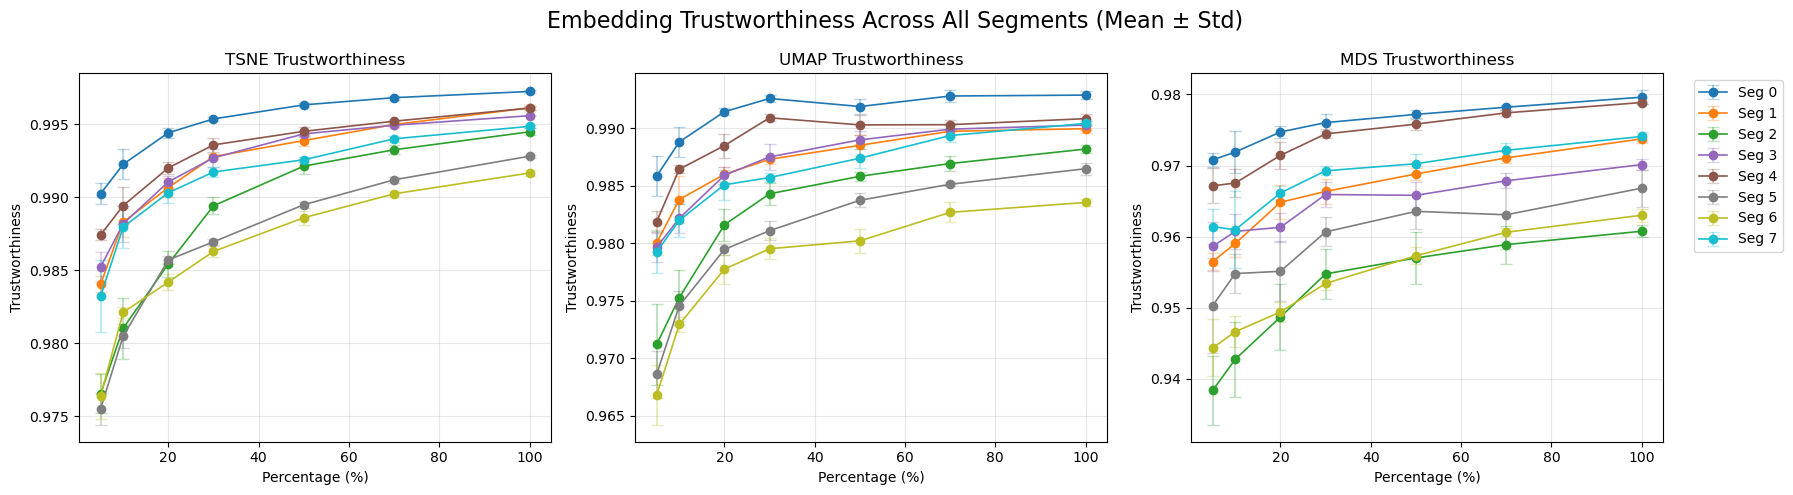

In [154]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

methods = ["tsne", "umap", "mds"]

# Compute mean and std per segment and percentage for trustworthiness
df_summary_trust = df_all_segments.groupby(['segment', 'percentage']).agg(
    tsne_trust_mean=('tsne_trustworthiness', 'mean'),
    tsne_trust_std=('tsne_trustworthiness', 'std'),
    umap_trust_mean=('umap_trustworthiness', 'mean'),
    umap_trust_std=('umap_trustworthiness', 'std'),
    mds_trust_mean=('mds_trustworthiness', 'mean'),
    mds_trust_std=('mds_trustworthiness', 'std')
).reset_index()

# Get colormap
segments = sorted(df_summary_trust['segment'].unique())
n_segments = len(segments)
cmap = cm.get_cmap('tab10', n_segments)  # adjust colormap if more than 10 segments

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18,5))

for ax, method in zip(axes, methods):
    
    for i, segment in enumerate(segments):
        df_seg = df_summary_trust[df_summary_trust['segment'] == segment]
        
        # Choose color for this segment
        color = cmap(i)
        color_err = (*color[:3], 0.3)  # same RGB, alpha=0.3 for error bars
        
        ax.errorbar(
            df_seg['percentage'],
            df_seg[f"{method}_trust_mean"],
            yerr=df_seg[f"{method}_trust_std"],
            marker='o',
            linewidth=1.2,
            capsize=4,
            label=f"Seg {segment}",
            color=color,       # line and marker
            ecolor=color_err,  # transparent error bars
            elinewidth=1.5
        )
    
    ax.set_title(f"{method.upper()} Trustworthiness")
    ax.set_xlabel("Percentage (%)")
    ax.set_ylabel("Trustworthiness")
    ax.grid(alpha=0.3)

axes[-1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.suptitle("Embedding Trustworthiness Across All Segments (Mean ± Std)", fontsize=16)
plt.tight_layout()
plt.show()